## Introduction to Gradient Descent

Gradient Descent is a fundamental, first-order iterative optimization algorithm used to find the local minimum of a differentiable function. The core idea is to take repeated steps in the opposite direction of the gradient (the slope) of the function at the current point, because this direction represents the steepest descent.

**The Intuition:**
Imagine you are blindfolded at the top of a rugged mountain, and your goal is to reach the lowest point in the valley. You cannot see the landscape, but you can feel the slope of the ground beneath your feet. To get to the bottom, you check which way slopes downward the most (the negative gradient) and take a step in that direction. You repeat this process until the ground is flat (the gradient is zero), indicating you have reached the valley floor.

**The Mathematics:**
Let $f(\theta)$ be the objective function (or cost function) we want to minimize, where $\theta$ represents the parameters of our system. The update rule for Gradient Descent is defined mathematically as:

$$\theta_{n+1} = \theta_n - \alpha \nabla f(\theta_n)$$

Where:
* $\theta_{n+1}$ is the new, updated position.
* $\theta_n$ is the current position.
* $\alpha$ is the **learning rate** (or step size). This is a critical hyperparameter that dictates how large of a step to take. If $\alpha$ is too small, convergence will be agonizingly slow. If $\alpha$ is too large, the algorithm might overshoot the minimum and diverge.
* $\nabla f(\theta_n)$ is the gradient of the function evaluated at the current position $\theta_n$. The gradient always points in the direction of the steepest *ascent*, which is why we subtract it to go downwards.

Converged after 38 iterations.


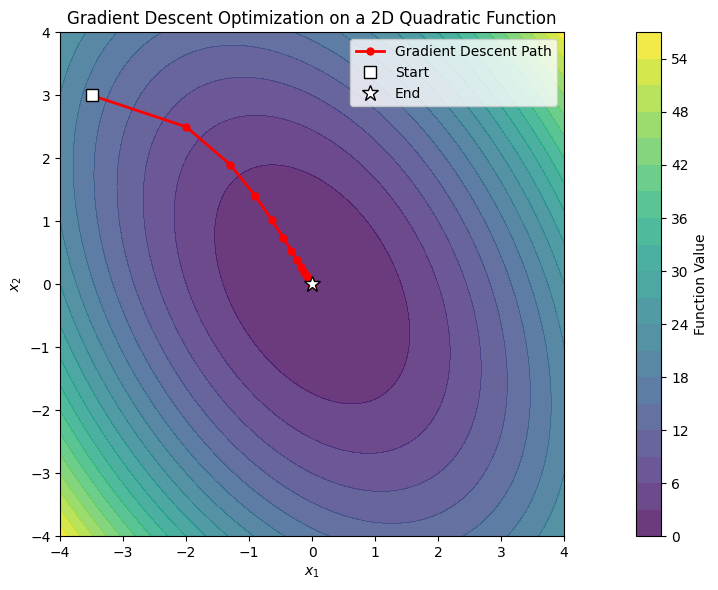

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Gradient Descent Algorithm
# ---------------------------------------------------------
def gradient_descent(f, grad_f, x0, step_size=0.1, max_iter=100, tol=1e-5):
    """
    Performs fixed-step gradient descent optimization.
    
    Parameters:
        f (callable): The objective function to minimize (unused in the update, but good for logging if needed).
        grad_f (callable): Function that returns the gradient of f at a given point.
        x0 (array-like): Initial starting point.
        step_size (float): Learning rate / step size.
        max_iter (int): Maximum number of iterations.
        tol (float): Tolerance for stopping criteria (norm of difference between consecutive points).
        
    Returns:
        np.ndarray: Array containing the history of points visited during optimization.
    """
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    
    for i in range(max_iter):
        grad = grad_f(x)
        x_new = x - step_size * grad
        
        history.append(x_new.copy())
        
        # Stopping criterion: if the step taken is smaller than the tolerance
        if np.linalg.norm(x_new - x) < tol:
            print(f"Converged after {i+1} iterations.")
            break
            
        x = x_new
        
    else:
        print(f"Reached maximum iterations ({max_iter}) without full convergence.")
        
    return np.array(history)


# ---------------------------------------------------------
# 2. 2D Quadratic Positive Definite Function
# ---------------------------------------------------------
# Let's define a quadratic form: f(x) = 0.5 * x^T * A * x
# A symmetric positive definite matrix A ensures a unique global minimum at the origin.
A = np.array([[3.0, 1.0], 
              [1.0, 2.0]])

def quad_func(x):
    """Evaluates the 2D quadratic function."""
    return 0.5 * x.T @ A @ x

def quad_grad(x):
    """Evaluates the gradient of the 2D quadratic function."""
    return A @ x


# ---------------------------------------------------------
# 3. Visualization Function
# ---------------------------------------------------------
def plot_optimization(f, history, x_bounds=(-4, 4), y_bounds=(-4, 4)):
    """
    Plots the filled contours of a 2D function and overlays the optimization history.
    """
    # Create a grid of points for the contour plot
    x_vals = np.linspace(x_bounds[0], x_bounds[1], 100)
    y_vals = np.linspace(y_bounds[0], y_bounds[1], 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    # Evaluate the function over the grid
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f(np.array([X[i, j], Y[i, j]]))
            
    # Plotting
    plt.figure(figsize=(8, 6))
    
    # Draw filled contours
    contour = plt.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.8)
    plt.colorbar(contour, label='Function Value')
    
    # Extract history coordinates
    hist_x = history[:, 0]
    hist_y = history[:, 1]
    
    # Plot the optimization trajectory
    plt.plot(hist_x, hist_y, 'ro-', markersize=5, linewidth=2, label='Gradient Descent Path')
    
    # Mark the start and end points
    plt.plot(hist_x[0], hist_y[0], 'ws', markersize=8, markeredgecolor='k', label='Start')
    plt.plot(hist_x[-1], hist_y[-1], 'w*', markersize=12, markeredgecolor='k', label='End')
    
    plt.title('Gradient Descent Optimization on a 2D Quadratic Function')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.tight_layout()
    plt.axis("scaled")
    plt.show()

# ---------------------------------------------------------
# Execution (Testing the functions)
# ---------------------------------------------------------
# Initial point
x_start = np.array([-3.5, 3.0])

# Run the optimization
opt_history = gradient_descent(f=quad_func, grad_f=quad_grad, x0=x_start, step_size=0.2, max_iter=50)

# Visualize the result
plot_optimization(f=quad_func, history=opt_history)

## Gradient Descent with Variable Step Size

Choosing the right learning rate ($\alpha$) in standard Gradient Descent is notoriously difficult. If it's too small, the algorithm is slow; if it's too large, it can overshoot the minimum and bounce around (or diverge entirely).

To solve this, we can introduce a **heuristic variable step size**. The logic is simple:
1. Propose a new point using the current step size.
2. Evaluate the function at this new point.
3. **If the function value decreases:** We are moving in the right direction safely. We **accept** the step and boldly increase the step size for the next iteration by a factor of $(1 + \rho)$.
4. **If the function value increases:** We overshot the minimum. We **reject** the step (stay where we are) and cautiously decrease the step size by a factor of $(1 - \rho)$.

Here, $\rho$ (rho) is a hyperparameter strictly less than 1 that controls how aggressively we scale our learning rate.

Converged after 38 iterations.


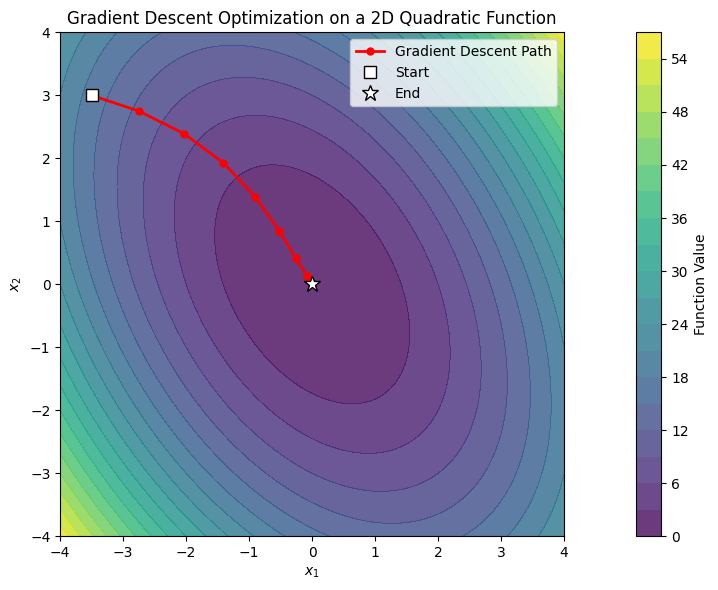

In [7]:
# ---------------------------------------------------------
# 4. Variable Step Gradient Descent Algorithm
# ---------------------------------------------------------
def gradient_descent_variable(f, grad_f, x0, step_size=0.1, max_iter=100, tol=1e-5, rho=0.2):
    """
    Performs gradient descent optimization with a heuristic variable step size.
    
    Parameters:
        f (callable): The objective function to minimize.
        grad_f (callable): Function that returns the gradient of f.
        x0 (array-like): Initial starting point.
        step_size (float): Initial learning rate / step size.
        max_iter (int): Maximum number of iterations.
        tol (float): Tolerance for stopping criteria.
        rho (float): Step size adjustment factor (0 < rho < 1).
        
    Returns:
        np.ndarray: Array containing the history of points visited.
    """
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    f_current = f(x)
    
    for i in range(max_iter):
        grad = grad_f(x)
        
        # Propose a new point
        x_new = x - step_size * grad
        f_new = f(x_new)
        
        # Check if the proposed point is strictly better
        if f_new < f_current:
            # Check stopping criterion before updating x
            if np.linalg.norm(x_new - x) < tol:
                history.append(x_new.copy())
                print(f"Converged after {i+1} iterations.")
                break
                
            # Accept the step
            x = x_new
            f_current = f_new
            step_size *= (1 + rho)  # Increase step size
            history.append(x.copy())
            
        else:
            # Reject the step
            step_size *= (1 - rho)  # Decrease step size
            # We don't update x or f_current, and we don't append to history
            
    else:
        print(f"Reached maximum iterations ({max_iter}) without full convergence.")
        
    return np.array(history)

# ---------------------------------------------------------
# Execution & Visualization
# ---------------------------------------------------------
# We use the same starting point and quadratic function defined in Cell 2
x_start = np.array([-3.5, 3.0])

# Run the adaptive optimization
# We can start with an intentionally poor (large) step size to see the algorithm correct itself
opt_history_var = gradient_descent_variable(
    f=quad_func, 
    grad_f=quad_grad, 
    x0=x_start, 
    step_size=0.1,  # Starting with a dangerously large step
    max_iter=50, 
    rho=0.3
)

# Visualize the result using our existing plotting function
plot_optimization(f=quad_func, history=opt_history_var)

## Theoretical Step Size Bounds for Quadratic Functions

When minimizing a strictly convex quadratic function $f(x) = \frac{1}{2} x^T A x$, the behavior of Gradient Descent is entirely governed by the eigenvalues of the symmetric positive definite matrix $A$.

Let the eigenvalues of $A$ be sorted such that $0 < \lambda_1 \le \lambda_2 \le \dots \le \lambda_n$. The geometry of the function is defined by these values: $\lambda_n$ represents the steepest curvature, and $\lambda_1$ represents the flattest curvature.

Based on these eigenvalues, we can determine exact theoretical limits for our fixed step size ($\alpha$):

**1. The Maximum Step Size (Stability Bound):**
If the step size is too large, the algorithm will overshoot the minimum and diverge. To guarantee convergence, the step size must be strictly less than:
$$\alpha_{max} = \frac{2}{\lambda_n(A)}$$

**2. The Optimal Fixed Step Size:**
If we must choose a single, fixed step size before running the algorithm, there is an optimal value that guarantees the fastest worst-case convergence rate. It balances the descent along the steepest and flattest directions:
$$\alpha_{opt} = \frac{2}{\lambda_1(A) + \lambda_n(A)}$$

--- Matrix Eigenvalue Analysis ---
Eigenvalues: lambda_1 (min) = 1.3820, lambda_n (max) = 3.6180
Condition Number (lambda_max/lambda_min): 2.6180

--- Step Size Theoretical Limits ---
Maximum Safe Step Size (alpha_max): 0.5528
Optimal Fixed Step Size (alpha_opt): 0.4000

Running Fixed Step Gradient Descent with alpha_opt...
Converged after 17 iterations.

Running Fixed Step Gradient Descent near alpha_max (oscillatory behavior)...
Reached maximum iterations (50) without full convergence.


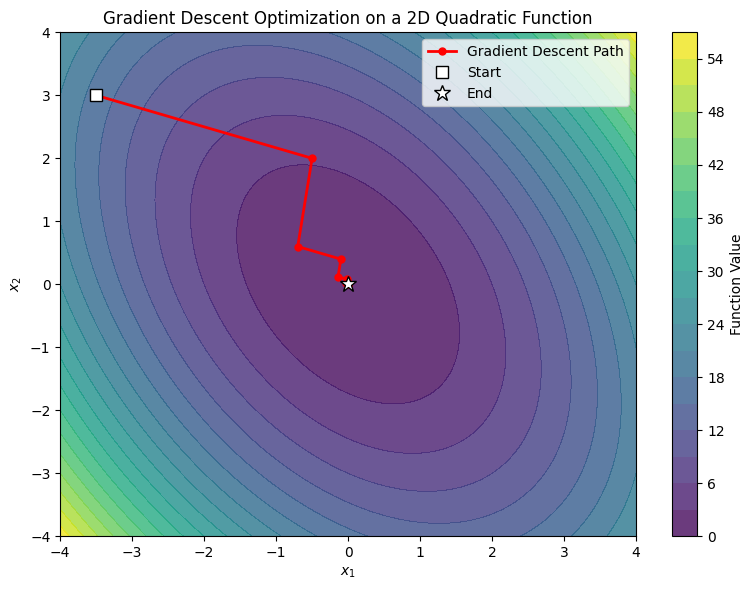

In [4]:
# ---------------------------------------------------------
# 5. Eigenvalue Analysis for Step Size
# ---------------------------------------------------------
def compute_step_bounds(matrix):
    """
    Computes the theoretical maximum and optimal step sizes 
    for a quadratic function defined by a symmetric positive definite matrix.
    
    Parameters:
        matrix (np.ndarray): The symmetric matrix A.
        
    Returns:
        tuple: (alpha_max, alpha_opt, lambda_min, lambda_max)
    """
    # Calculate the eigenvalues
    eigenvalues = np.linalg.eigvals(matrix)
    
    # Extract min and max eigenvalues
    lambda_min = np.min(eigenvalues)
    lambda_max = np.max(eigenvalues)
    
    # Compute the theoretical bounds
    alpha_max = 2.0 / lambda_max
    alpha_opt = 2.0 / (lambda_min + lambda_max)
    
    return alpha_max, alpha_opt, lambda_min, lambda_max

# Calculate the bounds for our matrix A (defined in Cell 2)
alpha_max, alpha_opt, l_min, l_max = compute_step_bounds(A)

print("--- Matrix Eigenvalue Analysis ---")
print(f"Eigenvalues: lambda_1 (min) = {l_min:.4f}, lambda_n (max) = {l_max:.4f}")
print(f"Condition Number (lambda_max/lambda_min): {l_max/l_min:.4f}\n")

print("--- Step Size Theoretical Limits ---")
print(f"Maximum Safe Step Size (alpha_max): {alpha_max:.4f}")
print(f"Optimal Fixed Step Size (alpha_opt): {alpha_opt:.4f}\n")

# ---------------------------------------------------------
# Execution & Comparison
# ---------------------------------------------------------
# 1. Run with the Optimal Fixed Step
print("Running Fixed Step Gradient Descent with alpha_opt...")
history_opt = gradient_descent(
    f=quad_func, 
    grad_f=quad_grad, 
    x0=x_start, 
    step_size=alpha_opt, 
    max_iter=50
)

# 2. Run with a Step Size extremely close to the theoretical maximum
print("\nRunning Fixed Step Gradient Descent near alpha_max (oscillatory behavior)...")
history_max = gradient_descent(
    f=quad_func, 
    grad_f=quad_grad, 
    x0=x_start, 
    step_size=alpha_max * 0.95, # 95% of the maximum allowed step
    max_iter=50
)

# Visualize the Optimal Step Size trajectory
plot_optimization(f=quad_func, history=history_opt)

# Note: You can change `history_opt` to `history_max` in the plotting 
# function above to see how drastically the trajectory changes and zig-zags 
# when the step size is near the instability threshold!

## Exact Line Search (Optimal Step Size)

Instead of using a fixed or heuristically adjusted step size, we can calculate the **exact optimal step size** at each iteration. For a strictly convex quadratic function $f(x) = \frac{1}{2} x^T A x$, this is computationally inexpensive and highly effective.

At a given point $x_n$ with gradient $g_n = \nabla f(x_n)$, we want to find the step size $t$ that minimizes the function along the search direction $-g_n$. Mathematically, we want to solve:
$$\min_{t > 0} f(x_n - t g_n)$$

Let's substitute our quadratic function into this expression:
$$f(x_n - t g_n) = \frac{1}{2} (x_n - t g_n)^T A (x_n - t g_n)$$

Expanding this and using the fact that $A x_n = g_n$, we get a function of $t$. To find its minimum, we take the derivative with respect to $t$ and set it to zero. This gives us a beautiful closed-form solution for the optimal step size $t^*$:
$$t^* = \frac{g_n^T g_n}{g_n^T A g_n}$$

Using this exact step size at every iteration guarantees maximum descent in the current gradient direction. Visually, this means each step will be perfectly orthogonal (at a 90-degree angle) to the previous one, creating a characteristic zig-zag path to the minimum.

Running Gradient Descent with Exact Line Search...
Converged after 17 iterations.


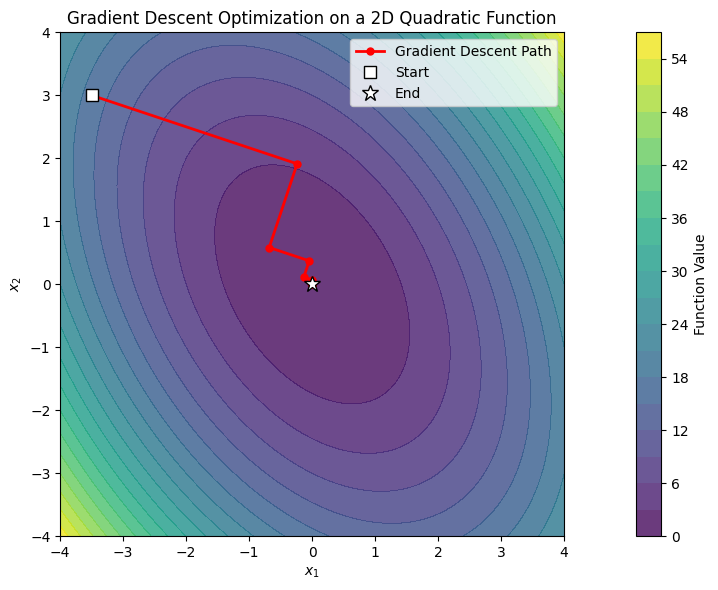

In [8]:
# ---------------------------------------------------------
# 6. Exact Line Search Step & Algorithm
# ---------------------------------------------------------
def compute_exact_step(grad, A_matrix):
    """
    Computes the exact optimal step size for a quadratic function.
    
    Parameters:
        grad (np.ndarray): The gradient at the current point.
        A_matrix (np.ndarray): The symmetric positive definite matrix A.
        
    Returns:
        float: The optimal step size t*.
    """
    numerator = grad.T @ grad
    denominator = grad.T @ A_matrix @ grad
    
    # Prevent division by zero if we are exactly at the minimum (gradient is 0)
    if denominator == 0:
        return 0.0
        
    return numerator / denominator

def gradient_descent_exact(f, grad_f, A_matrix, x0, max_iter=100, tol=1e-5):
    """
    Performs gradient descent using the exact optimal step size at each iteration.
    """
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    
    for i in range(max_iter):
        grad = grad_f(x)
        
        # Check stopping criterion based on the norm of the gradient
        if np.linalg.norm(grad) < tol:
            print(f"Converged after {i} iterations.")
            break
            
        # 1. Compute the exact optimal step size for this specific position
        t_opt = compute_exact_step(grad, A_matrix)
        
        # 2. Update position
        x_new = x - t_opt * grad
        history.append(x_new.copy())
        
        x = x_new
        
    else:
        print(f"Reached maximum iterations ({max_iter}) without full convergence.")
        
    return np.array(history)

# ---------------------------------------------------------
# Execution & Visualization
# ---------------------------------------------------------
print("Running Gradient Descent with Exact Line Search...")

# We use the same starting point and matrix A from previous cells
opt_history_exact = gradient_descent_exact(
    f=quad_func, 
    grad_f=quad_grad, 
    A_matrix=A, 
    x0=x_start, 
    max_iter=50
)

# Visualize the result
# Notice the perfect 90-degree angles between consecutive steps!
plot_optimization(f=quad_func, history=opt_history_exact)

## The Conjugate Gradient (CG) Method

While Gradient Descent with Exact Line Search guarantees optimal descent at each individual step, it suffers from a major flaw: it constantly undoes its own progress. Because each step is orthogonal (at a 90-degree angle) to the previous one, the algorithm "zig-zags" back and forth across the valley, often repeating search directions multiple times. 

The **Conjugate Gradient (CG)** method solves this. Instead of moving in orthogonal directions, it moves in **$A$-orthogonal** (or *conjugate*) directions. 

Two vectors $p_1$ and $p_2$ are $A$-orthogonal if:
$$p_1^T A p_2 = 0$$

**The Magic of CG:**
When minimizing a quadratic function $f(x) = \frac{1}{2}x^T A x - b^T x$, if we take exact steps along $A$-orthogonal directions, we never spoil the minimization achieved in previous steps. 

Because there are exactly $n$ mutually $A$-orthogonal directions in an $n$-dimensional space, **the Conjugate Gradient method is theoretically guaranteed to find the exact global minimum of an $n$-dimensional quadratic function in at most $n$ iterations!**

**The Algorithm (for solving $Ax = b$):**
In our case, minimizing $\frac{1}{2}x^T A x$ is equivalent to solving $Ax = 0$ (so $b = \mathbf{0}$). 
Let $r_k = b - Ax_k$ be the residual (which is exactly the negative gradient, $-\nabla f(x_k)$).

1. Initialize: $r_0 = b - Ax_0$, and set initial search direction $p_0 = r_0$.
2. For $k = 0, 1, 2, \dots$:
   * Compute step size: $\alpha_k = \frac{r_k^T r_k}{p_k^T A p_k}$
   * Update position: $x_{k+1} = x_k + \alpha_k p_k$
   * Update residual: $r_{k+1} = r_k - \alpha_k A p_k$
   * Compute conjugation factor: $\beta_k = \frac{r_{k+1}^T r_{k+1}}{r_k^T r_k}$
   * Update search direction: $p_{k+1} = r_{k+1} + \beta_k p_k$

Running Conjugate Gradient Method...
Converged after 2 iterations.


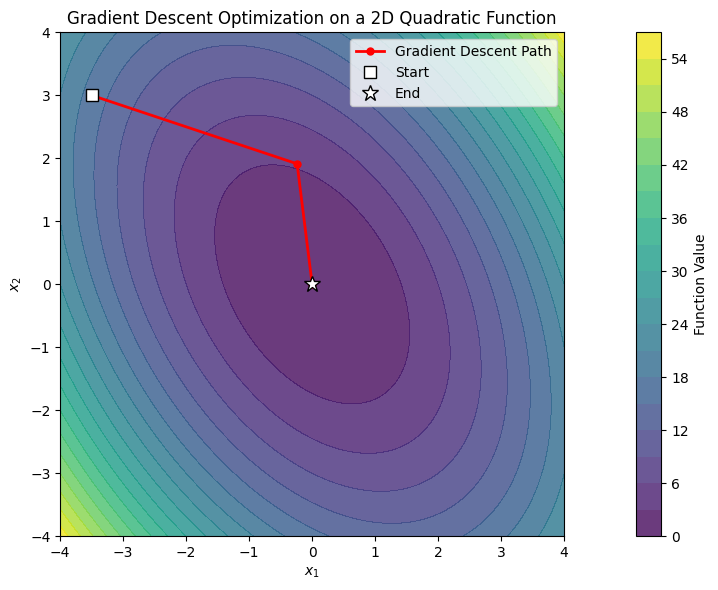

In [9]:
# ---------------------------------------------------------
# 7. Conjugate Gradient Algorithm
# ---------------------------------------------------------
def conjugate_gradient(A_matrix, b_vector, x0, tol=1e-5):
    """
    Performs the linear Conjugate Gradient optimization.
    
    Parameters:
        A_matrix (np.ndarray): The symmetric positive definite matrix A.
        b_vector (np.ndarray): The vector b.
        x0 (array-like): Initial starting point.
        tol (float): Tolerance for stopping criteria based on the residual norm.
        
    Returns:
        np.ndarray: Array containing the history of points visited.
    """
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    
    # Initialize the residual (negative gradient) and search direction
    r = b_vector - A_matrix @ x
    p = r.copy()
    
    # For an n-dimensional problem, CG should theoretically converge in n steps.
    # We loop up to n + 1 just to account for slight floating point inaccuracies.
    n_dims = len(b_vector)
    
    for i in range(n_dims + 1): 
        # Check if we are already at the minimum
        if np.linalg.norm(r) < tol:
            print(f"Converged after {i} iterations.")
            break
            
        # Matrix-vector product (computed once per iteration for efficiency)
        Ap = A_matrix @ p
        
        # 1. Compute exact step size alpha
        alpha = (r.T @ r) / (p.T @ Ap)
        
        # 2. Update position
        x = x + alpha * p
        history.append(x.copy())
        
        # 3. Update residual
        r_new = r - alpha * Ap
        
        # Check stopping criterion on the new residual
        if np.linalg.norm(r_new) < tol:
            print(f"Converged after {i+1} iterations.")
            break
            
        # 4. Compute conjugation factor beta
        beta = (r_new.T @ r_new) / (r.T @ r)
        
        # 5. Update search direction
        p = r_new + beta * p
        
        # Prepare for next iteration
        r = r_new
        
    else:
        print("Failed to converge within expected number of iterations due to numerical instability.")
        
    return np.array(history)

# ---------------------------------------------------------
# Execution & Visualization
# ---------------------------------------------------------
print("Running Conjugate Gradient Method...")

# Since our quadratic function is f(x) = 0.5 * x^T * A * x
# The equivalent linear system is Ax = 0, so our b vector is [0, 0]^T
b = np.array([0.0, 0.0])

# Run the optimization using the same starting point and matrix A
opt_history_cg = conjugate_gradient(
    A_matrix=A, 
    b_vector=b, 
    x0=x_start
)

# Visualize the result
plot_optimization(f=quad_func, history=opt_history_cg)

# Note for the students: Look at the console output and the plot! 
# Because we are in 2 dimensions, CG reaches the exact center in precisely 2 steps.

## The Peril of Saddle Points in Non-Convex Functions

So far, we have only optimized strictly convex quadratic functions, which have a single, beautifully defined global minimum. Real-world problems (like training neural networks) are highly **non-convex**. They contain multiple local minima and saddle points.

A **saddle point** is a point where the gradient is zero, but it is not a local minimum or maximum. The function curves upwards in some directions and downwards in others (like the shape of a horse's saddle).

To illustrate this, let's explore the function:
$$f(x, y) = (x^2 - 1)^2 (y^2 + 1) + 0.2y^2$$

**Analytical Properties:**
1. **Local Minima:** The function has two distinct local (and global) minima at $(1, 0)$ and $(-1, 0)$.
2. **Saddle Point:** There is a critical point at $(0, 0)$. If you look at the $y$-direction, it looks like a minimum. But in the $x$-direction, it looks like a maximum.

**The Experiment:**
We will run our Variable Step Gradient Descent from two almost identical starting points:
* **Initialization 1:** $(0, 1.5)$. Here, the algorithm is perfectly aligned with the saddle point's "ridge." The $x$-component of the gradient is exactly zero, so it will only move along the $y$-axis and get trapped at $(0, 0)$.
* **Initialization 2:** $(10^{-6}, 1.5)$. By adding an infinitesimally small perturbation to the $x$-coordinate, we break the symmetry. The algorithm will eventually "feel" the slope in the $x$-direction, slide off the saddle, and find the true minimum at $(1, 0)$.

Running from (0, 1.5)...
Converged after 16 iterations.

Running from (10^-6, 1.5)...
Reached maximum iterations (150) without full convergence.


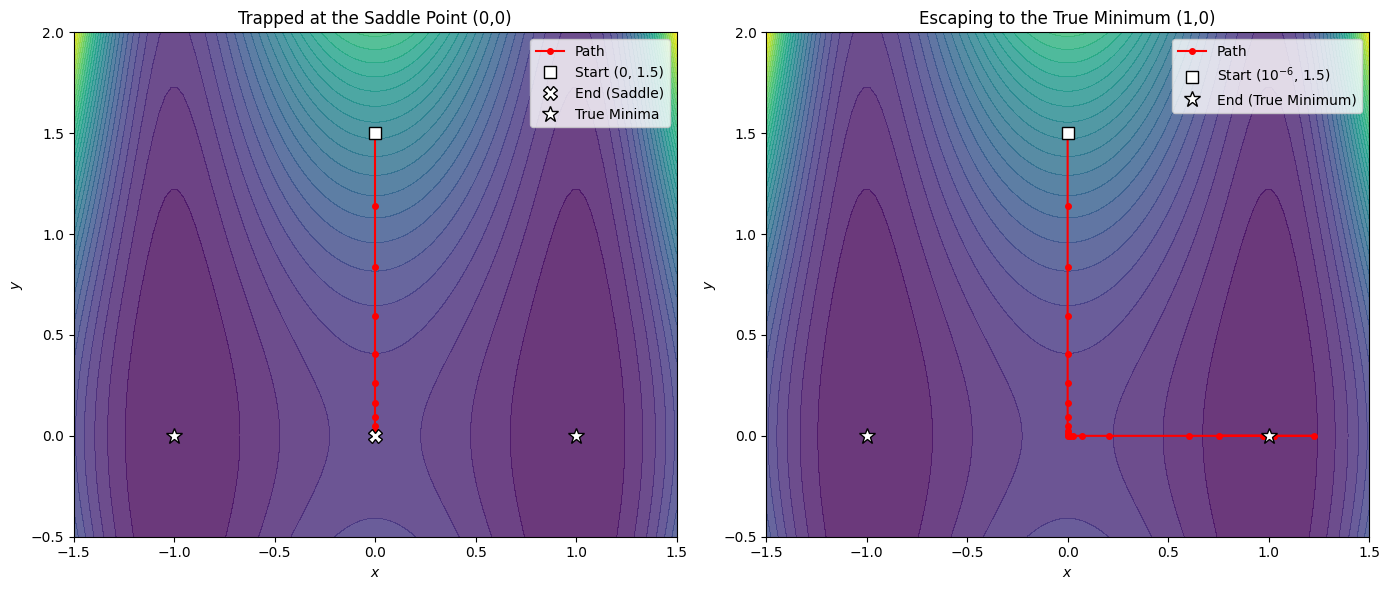

In [10]:
# ---------------------------------------------------------
# 8. Non-Convex Function and Saddle Point Experiment
# ---------------------------------------------------------
def non_convex_func(v):
    """Evaluates the non-convex function."""
    x, y = v[0], v[1]
    return (x**2 - 1)**2 * (y**2 + 1) + 0.2 * y**2

def non_convex_grad(v):
    """Evaluates the gradient of the non-convex function."""
    x, y = v[0], v[1]
    df_dx = 4 * x * (x**2 - 1) * (y**2 + 1)
    df_dy = 2 * y * (x**2 - 1)**2 + 0.4 * y
    return np.array([df_dx, df_dy])

# Initializations
start_saddle = np.array([0.0, 1.5])
start_perturbed = np.array([1e-6, 1.5])

# Run Variable Step Gradient Descent for both
print("Running from (0, 1.5)...")
history_saddle = gradient_descent_variable(
    f=non_convex_func, grad_f=non_convex_grad, 
    x0=start_saddle, step_size=0.1, max_iter=150, rho=0.1
)

print("\nRunning from (10^-6, 1.5)...")
history_perturbed = gradient_descent_variable(
    f=non_convex_func, grad_f=non_convex_grad, 
    x0=start_perturbed, step_size=0.1, max_iter=150, rho=0.1
)

# ---------------------------------------------------------
# Custom Visualization for Side-by-Side Comparison
# ---------------------------------------------------------
def plot_saddle_comparison(f, hist1, hist2):
    x_vals = np.linspace(-1.5, 1.5, 100)
    y_vals = np.linspace(-0.5, 2.0, 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f(np.array([X[i, j], Y[i, j]]))
            
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Trapped in Saddle
    contour1 = ax1.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.8)
    ax1.plot(hist1[:, 0], hist1[:, 1], 'ro-', markersize=4, label='Path')
    ax1.plot(hist1[0, 0], hist1[0, 1], 'ws', markersize=8, markeredgecolor='k', label='Start (0, 1.5)')
    ax1.plot(hist1[-1, 0], hist1[-1, 1], 'wX', markersize=10, markeredgecolor='k', label='End (Saddle)')
    ax1.plot([1, -1], [0, 0], 'w*', markersize=12, markeredgecolor='k', label='True Minima')
    ax1.set_title('Trapped at the Saddle Point (0,0)')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$y$')
    ax1.legend()
    
    # Plot 2: Escaping to Minimum
    contour2 = ax2.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.8)
    ax2.plot(hist2[:, 0], hist2[:, 1], 'ro-', markersize=4, label='Path')
    ax2.plot(hist2[0, 0], hist2[0, 1], 'ws', markersize=8, markeredgecolor='k', label='Start ($10^{-6}$, 1.5)')
    ax2.plot(hist2[-1, 0], hist2[-1, 1], 'w*', markersize=12, markeredgecolor='k', label='End (True Minimum)')
    ax2.plot(-1, 0, 'w*', markersize=12, markeredgecolor='k') # Other minimum
    ax2.set_title('Escaping to the True Minimum (1,0)')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$y$')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Visualize
plot_saddle_comparison(non_convex_func, history_saddle, history_perturbed)

## The Curse of Ill-Conditioning

In optimization, convergence guarantees are only part of the story. The *speed* of convergence is heavily dictated by the geometry of the function, specifically its **condition number**. 

For a quadratic function $f(x) = \frac{1}{2}x^T A x$, the condition number $\kappa$ is the ratio of the largest to the smallest eigenvalue of the matrix $A$:
$$\kappa(A) = \frac{\lambda_{max}}{\lambda_{min}}$$

* **Well-conditioned ($\kappa \approx 1$):** The contours of the function look like perfect circles (or spheres). The negative gradient points almost exactly toward the global minimum.
* **Ill-conditioned ($\kappa \gg 1$):** The contours look like highly stretched ellipses, forming a long, narrow "ravine" or "valley." 

**Why is this a problem?**
In an ill-conditioned ravine, the gradient is extremely steep across the narrow walls but almost perfectly flat along the valley floor. When Gradient Descent takes a step, it bounces violently from wall to wall (zig-zagging) while making agonizingly slow progress toward the minimum. 

Even with **Exact Line Search**, which guarantees optimal descent at each step, the orthogonal nature of the steps forces the algorithm to repeat directions, leading to severe slowdowns. Let's construct a highly ill-conditioned matrix to see this in action and compare it against our Conjugate Gradient implementation.

--- Ill-Conditioned Matrix Analysis ---
Smallest Eigenvalue (lambda_min): 0.0500
Largest Eigenvalue (lambda_max):  50.0000
Condition Number (kappa):         1000.00
Notice how large kappa is compared to our previous matrix!

Running Exact Line Search Gradient Descent...
Converged after 9 iterations.

Running Conjugate Gradient...
Converged after 2 iterations.


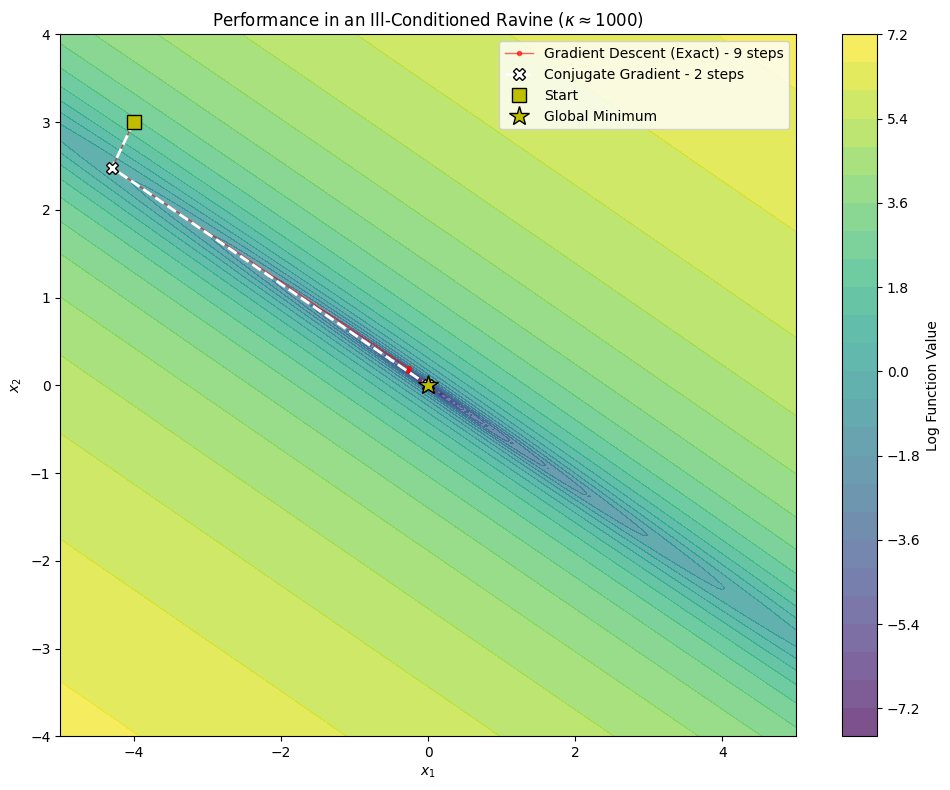

In [14]:
# ---------------------------------------------------------
# 9. Ill-Conditioned Quadratic Example
# ---------------------------------------------------------
# Create a highly stretched, rotated matrix A to simulate a narrow ravine
theta = np.pi / 6  # Rotate by 30 degrees so it's not perfectly axis-aligned
R = np.array([[np.cos(theta), -np.sin(theta)], 
              [np.sin(theta),  np.cos(theta)]])

# Set extreme eigenvalues: one very small (flat), one very large (steep)
Lambda = np.array([[0.05, 0.0], 
                   [0.0, 50.0]])

A_ill = R.T @ Lambda @ R

# Define the ill-conditioned functions
def ill_func(x):
    return 0.5 * x.T @ A_ill @ x

def ill_grad(x):
    return A_ill @ x

# 1. Analyze the Condition Number
alpha_max_ill, alpha_opt_ill, l_min_ill, l_max_ill = compute_step_bounds(A_ill)
cond_number = l_max_ill / l_min_ill

print("--- Ill-Conditioned Matrix Analysis ---")
print(f"Smallest Eigenvalue (lambda_min): {l_min_ill:.4f}")
print(f"Largest Eigenvalue (lambda_max):  {l_max_ill:.4f}")
print(f"Condition Number (kappa):         {cond_number:.2f}")
print("Notice how large kappa is compared to our previous matrix!\n")

# ---------------------------------------------------------
# Execution: Gradient Descent vs. Conjugate Gradient
# ---------------------------------------------------------
x_start_ill = np.array([-4.0, 3.0])

print("Running Exact Line Search Gradient Descent...")
# We give it a generous 100 iterations
history_gd_ill = gradient_descent_exact(
    f=ill_func, grad_f=ill_grad, A_matrix=A_ill, 
    x0=x_start_ill, max_iter=100
)

print("\nRunning Conjugate Gradient...")
b_zero = np.array([0.0, 0.0])
history_cg_ill = conjugate_gradient(
    A_matrix=A_ill, b_vector=b_zero, x0=x_start_ill
)

# ---------------------------------------------------------
# Custom Visualization for Comparison
# ---------------------------------------------------------
def plot_ill_conditioned_comparison(f, hist_gd, hist_cg):
    x_vals = np.linspace(-5, 5, 200)
    y_vals = np.linspace(-4, 4, 200)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f(np.array([X[i, j], Y[i, j]]))
            
    plt.figure(figsize=(10, 8))
    
    # We use a log scale for the contours to better visualize the narrow valley
    contour = plt.contourf(X, Y, np.log(Z + 1e-10), levels=25, cmap='viridis', alpha=0.7)
    plt.colorbar(contour, label='Log Function Value')
    
    # Plot Gradient Descent Path (make it slightly transparent to see the mess)
    plt.plot(hist_gd[:, 0], hist_gd[:, 1], 'ro-', markersize=3, linewidth=1, 
             alpha=0.6, label=f'Gradient Descent (Exact) - {len(hist_gd)-1} steps')
    
    # Plot Conjugate Gradient Path (make it bold)
    plt.plot(hist_cg[:, 0], hist_cg[:, 1], 'wX--', markersize=8, linewidth=2, 
             markeredgecolor='k', label=f'Conjugate Gradient - {len(hist_cg)-1} steps')
    
    # Mark start and true minimum
    plt.plot(x_start_ill[0], x_start_ill[1], 'ys', markersize=10, markeredgecolor='k', label='Start')
    plt.plot(0, 0, 'y*', markersize=15, markeredgecolor='k', label='Global Minimum')
    
    plt.title(fr'Performance in an Ill-Conditioned Ravine ($\kappa \approx {cond_number:.0f}$)')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Visualize the massacre
plot_ill_conditioned_comparison(ill_func, history_gd_ill, history_cg_ill)

Running Fixed Step Gradient Descent (alpha = 0.038)...
Reached maximum iterations (300) without full convergence.

Running Variable Step Gradient Descent...
Reached maximum iterations (300) without full convergence.


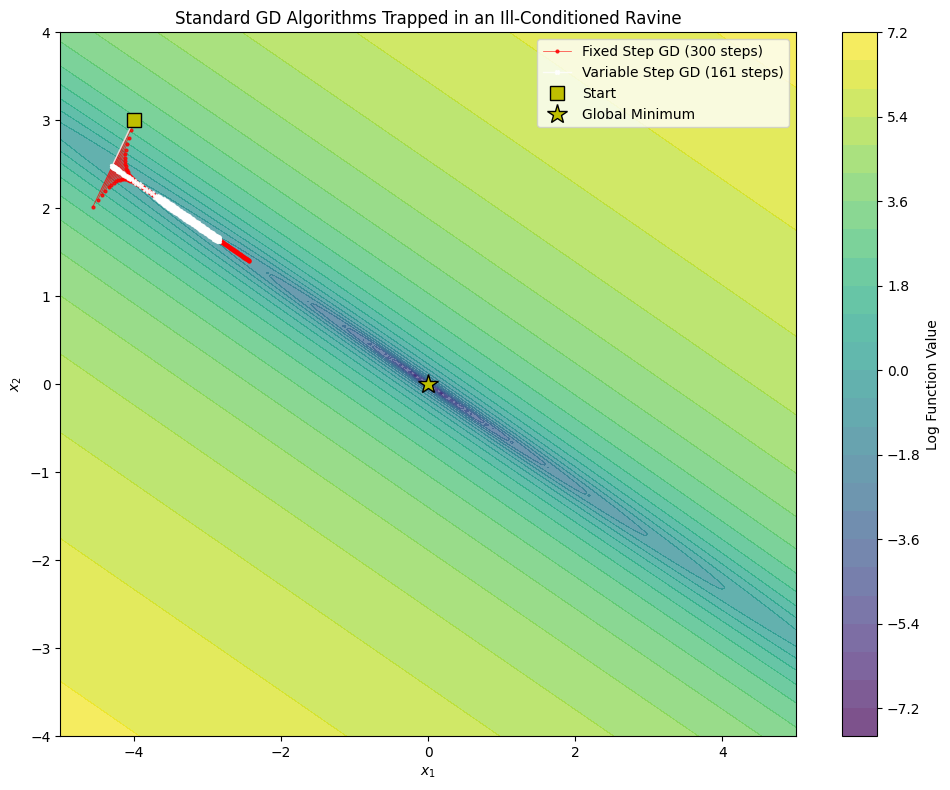

In [15]:
# ---------------------------------------------------------
# 10. Fixed and Variable Step on Ill-Conditioned Function
# ---------------------------------------------------------
print("Running Fixed Step Gradient Descent (alpha = 0.038)...")
history_fixed_ill = gradient_descent(
    f=ill_func, 
    grad_f=ill_grad, 
    x0=x_start_ill, 
    step_size=0.038, # Just below the theoretical maximum of ~0.04
    max_iter=300
)

print("\nRunning Variable Step Gradient Descent...")
history_var_ill = gradient_descent_variable(
    f=ill_func, 
    grad_f=ill_grad, 
    x0=x_start_ill, 
    step_size=0.02,  # Start conservative
    max_iter=300, 
    rho=0.1
)

# ---------------------------------------------------------
# Custom Visualization
# ---------------------------------------------------------
def plot_standard_gd_ill(f, hist_fixed, hist_var):
    x_vals = np.linspace(-5, 5, 200)
    y_vals = np.linspace(-4, 4, 200)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f(np.array([X[i, j], Y[i, j]]))
            
    plt.figure(figsize=(10, 8))
    
    # Log scale contours
    contour = plt.contourf(X, Y, np.log(Z + 1e-10), levels=25, cmap='viridis', alpha=0.7)
    plt.colorbar(contour, label='Log Function Value')
    
    # Plot Fixed Step
    plt.plot(hist_fixed[:, 0], hist_fixed[:, 1], 'ro-', markersize=2, linewidth=0.5, 
             alpha=0.8, label=f'Fixed Step GD ({len(hist_fixed)-1} steps)')
    
    # Plot Variable Step
    plt.plot(hist_var[:, 0], hist_var[:, 1], 'wX-', markersize=3, linewidth=1, 
             alpha=0.8, label=f'Variable Step GD ({len(hist_var)-1} steps)')
    
    # Mark start and true minimum
    plt.plot(x_start_ill[0], x_start_ill[1], 'ys', markersize=10, markeredgecolor='k', label='Start')
    plt.plot(0, 0, 'y*', markersize=15, markeredgecolor='k', label='Global Minimum')
    
    plt.title(r'Standard GD Algorithms Trapped in an Ill-Conditioned Ravine')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Visualize the comparison
plot_standard_gd_ill(ill_func, history_fixed_ill, history_var_ill)

# Note: Compare these hundreds of zig-zagging steps to the 2 steps taken by Conjugate Gradient!

## Newton's Method: Harnessing Second-Order Information

Gradient Descent only looks at the **first derivative** (the gradient). It knows the slope beneath its feet, but it is completely blind to the overall curvature of the landscape. This is why it gets trapped bouncing off the walls of our ill-conditioned ravine.

**Newton's Method** solves this by using **second derivatives**—collected in a matrix called the **Hessian** ($\nabla^2 f(x)$). 

By using both the gradient and the Hessian, Newton's Method builds a local, perfectly fitting quadratic approximation of the landscape and jumps directly to the bottom of that bowl.

**The Mathematics:**
The update rule for Newton's Method is:
$$x_{n+1} = x_n - [\nabla^2 f(x_n)]^{-1} \nabla f(x_n)$$

**Why does this fix ill-conditioning?**
Multiplying the gradient by the inverse of the Hessian acts as an automatic, perfect scaling factor. It dramatically reduces the step size in the highly curved directions (stopping the bouncing) and massively increases the step size in the flat directions (accelerating progress). 

**The Magic for Quadratic Functions:**
Because our objective function $f(x) = \frac{1}{2} x^T A x$ is *already* a perfect quadratic function, Newton's local quadratic approximation isn't just an approximation—it's the exact function! 

Therefore, for any strictly convex quadratic function, regardless of how terribly ill-conditioned it is, **Newton's Method will reach the exact global minimum in exactly ONE step.** Let's prove it.

Running Newton's Method on the Ill-Conditioned Ravine...
Converged after 1 iterations.


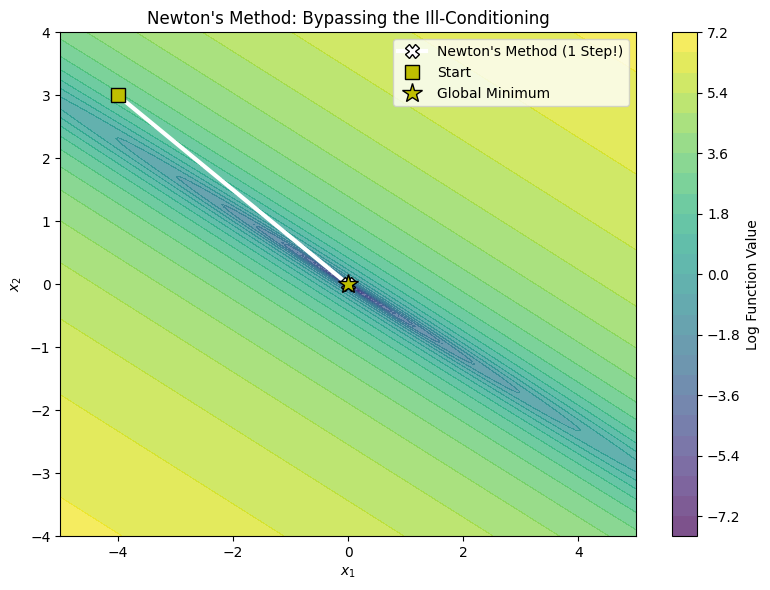

In [16]:
# ---------------------------------------------------------
# 11. Newton's Method Implementation
# ---------------------------------------------------------
def newtons_method(f, grad_f, hess_f, x0, max_iter=10, tol=1e-5):
    """
    Performs Newton's Method optimization.
    
    Parameters:
        f (callable): The objective function.
        grad_f (callable): Function that returns the gradient.
        hess_f (callable): Function that returns the Hessian matrix.
        x0 (array-like): Initial starting point.
        max_iter (int): Maximum number of iterations.
        tol (float): Tolerance for stopping criteria.
        
    Returns:
        np.ndarray: Array containing the history of points visited.
    """
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    
    for i in range(max_iter):
        grad = grad_f(x)
        
        # Stopping criterion
        if np.linalg.norm(grad) < tol:
            print(f"Converged after {i} iterations.")
            break
            
        H = hess_f(x)
        
        # Instead of explicitly computing the inverse (which is computationally 
        # expensive and numerically unstable), we solve the linear system:
        # H * step = -gradient
        # step = -H^{-1} * gradient
        step = np.linalg.solve(H, -grad)
        
        # Update position
        x_new = x + step
        history.append(x_new.copy())
        x = x_new
        
    else:
        print("Failed to converge.")
        
    return np.array(history)

# ---------------------------------------------------------
# Execution on the Ill-Conditioned Ravine
# ---------------------------------------------------------
# For our quadratic function f(x) = 0.5 * x^T * A_ill * x
# The gradient is A_ill * x
# The Hessian (second derivative) is simply the matrix A_ill itself!

def ill_hessian(x):
    """Returns the Hessian of the ill-conditioned quadratic."""
    return A_ill

print("Running Newton's Method on the Ill-Conditioned Ravine...")
history_newton = newtons_method(
    f=ill_func, 
    grad_f=ill_grad, 
    hess_f=ill_hessian, 
    x0=x_start_ill
)

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
def plot_newton_triumph(f, hist_newton):
    x_vals = np.linspace(-5, 5, 200)
    y_vals = np.linspace(-4, 4, 200)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f(np.array([X[i, j], Y[i, j]]))
            
    plt.figure(figsize=(8, 6))
    
    # Log scale contours for the ravine
    contour = plt.contourf(X, Y, np.log(Z + 1e-10), levels=25, cmap='viridis', alpha=0.7)
    plt.colorbar(contour, label='Log Function Value')
    
    # Plot Newton's Method path
    plt.plot(hist_newton[:, 0], hist_newton[:, 1], 'wX-', markersize=10, linewidth=3, 
             markeredgecolor='k', label="Newton's Method (1 Step!)")
    
    # Mark start and true minimum
    plt.plot(x_start_ill[0], x_start_ill[1], 'ys', markersize=10, markeredgecolor='k', label='Start')
    plt.plot(0, 0, 'y*', markersize=15, markeredgecolor='k', label='Global Minimum')
    
    plt.title(fr"Newton's Method: Bypassing the Ill-Conditioning")
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Visualize the single-step victory
plot_newton_triumph(ill_func, history_newton)